In [3]:
pip install scikit-learn pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


                precision    recall  f1-score   support

An. arabiensis       0.97      0.98      0.98       600
  An. coluzzii       0.91      0.91      0.91       600
   An. gambiae       0.92      0.91      0.91       600

      accuracy                           0.93      1800
     macro avg       0.93      0.93      0.93      1800
  weighted avg       0.93      0.93      0.93      1800



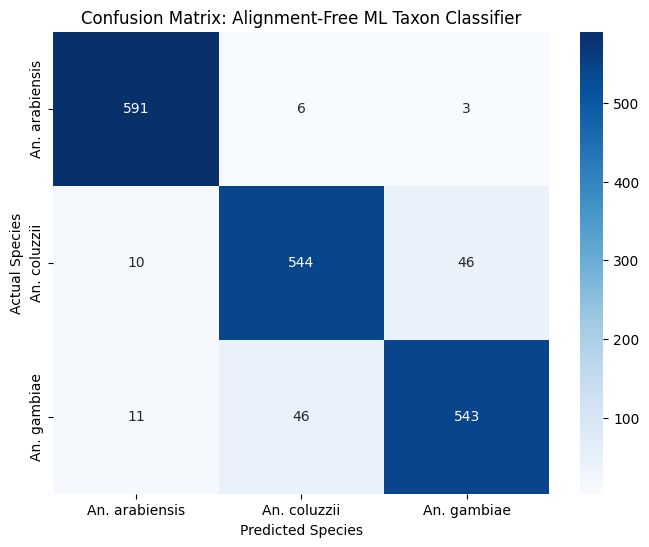

In [4]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# 1. Simulate Evolutionary Divergence from an Ancestral Genome
bases = ['A', 'C', 'G', 'T']
genome_length = 50000
ancestor = np.random.choice(bases, size=genome_length)

def mutate_genome(genome, mutation_rate):
    mutated = genome.copy()
    num_mutations = int(len(genome) * mutation_rate)
    indices = np.random.choice(len(genome), size=num_mutations, replace=False)
    for idx in indices:
        current_base = mutated[idx]
        possible_bases = [b for b in bases if b != current_base]
        mutated[idx] = np.random.choice(possible_bases)
    return mutated

species_genomes = {
    "An. gambiae": mutate_genome(ancestor, 0.02),
    "An. coluzzii": mutate_genome(ancestor, 0.03),
    "An. arabiensis": mutate_genome(ancestor, 0.08)
}

# 2. Simulate Illumina-style Sequencing Reads with Error Rates
def generate_reads(genome, num_reads, read_len, error_rate=0.01):
    reads = []
    for _ in range(num_reads):
        start = np.random.randint(0, len(genome) - read_len)
        read = genome[start:start+read_len].copy()
        
        err_indices = np.random.rand(read_len) < error_rate
        for i in np.where(err_indices)[0]:
            read[i] = np.random.choice(bases)
        reads.append("".join(read))
    return reads

data = []
labels = []
for species, genome in species_genomes.items():
    species_reads = generate_reads(genome, num_reads=3000, read_len=150)
    data.extend(species_reads)
    labels.extend([species] * len(species_reads))

df = pd.DataFrame({"read_sequence": data, "species": labels})

# 3. Extract Features using TF-IDF on 5-mers
vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(5, 5), max_features=2500)
X = vectorizer.fit_transform(df['read_sequence'])
y = df['species']

# 4. Train Random Forest Classifier
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
clf = RandomForestClassifier(n_estimators=150, max_depth=None, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

# 5. Evaluate and Plot
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.title("Confusion Matrix: Alignment-Free ML Taxon Classifier")
plt.ylabel("Actual Species")
plt.xlabel("Predicted Species")
plt.show()